<a href="https://colab.research.google.com/github/joshna-pinto/-YuvaIntern-Week3-Clustering/blob/main/Copy_of_Week3_Wholesale_Customer_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Wholesale customers data.txt', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Wholesale customers data.txt")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (440, 8)

First 5 rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [ ]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDescriptive statistics:")
print(df.describe())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows:
0

Descriptive statistics:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000

In [ ]:
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features]

print("Features used for clustering:")
print(X.head())

print("\nShape of clustering data:", X.shape)

Features used for clustering:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185

Shape of clustering data: (440, 6)


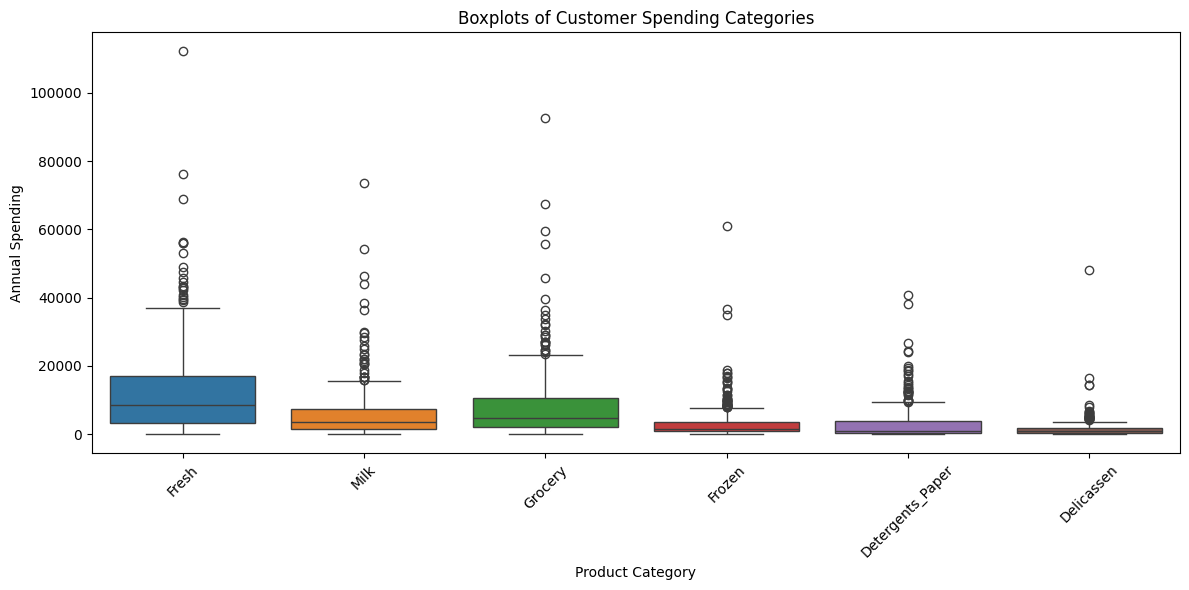

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.title("Boxplots of Customer Spending Categories")
plt.xlabel("Product Category")
plt.ylabel("Annual Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

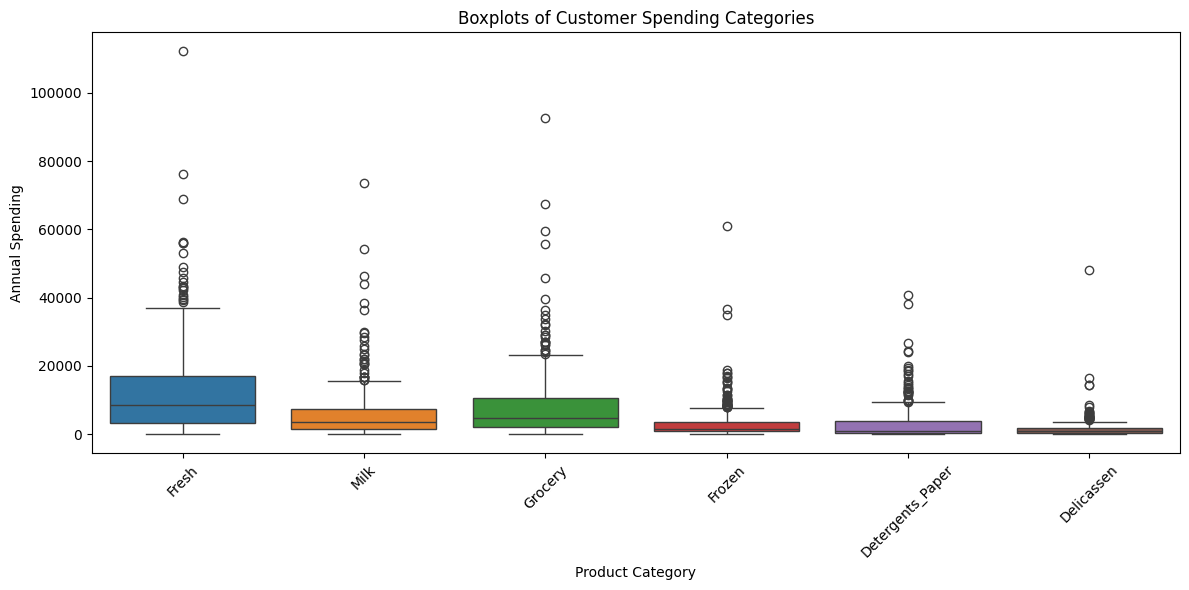

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.title("Boxplots of Customer Spending Categories")
plt.xlabel("Product Category")
plt.ylabel("Annual Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Apply log transformation to reduce the effect of extreme values
X_log = np.log1p(X)

print("Skewness before log transformation:")
print(X.skew().round(2))

print("\nSkewness after log transformation:")
print(X_log.skew().round(2))

Skewness before log transformation:
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64

Skewness after log transformation:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

# Convert back to DataFrame for easier analysis
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Standardized data:")
print(X_scaled.head())

print("\nMean after standardization:")
print(X_scaled.mean().round(2))

print("\nStandard deviation after standardization:")
print(X_scaled.std().round(2))

Standardized data:
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.486184  0.976299  0.440155 -1.509250          0.644143    0.408966
1  0.087889  0.990956  0.652171  0.134052          0.766043    0.627926
2  0.016356  0.891151  0.454687  0.376899          0.804405    1.776833
3  0.517477 -0.957973 -0.084792  1.141574         -0.328712    0.633133
4  0.880631  0.439662  0.395847  0.757322          0.404939    1.456588

Mean after standardization:
Fresh               0.0
Milk               -0.0
Grocery            -0.0
Frozen              0.0
Detergents_Paper   -0.0
Delicassen         -0.0
dtype: float64

Standard deviation after standardization:
Fresh               1.0
Milk                1.0
Grocery             1.0
Frozen              1.0
Detergents_Paper    1.0
Delicassen          1.0
dtype: float64


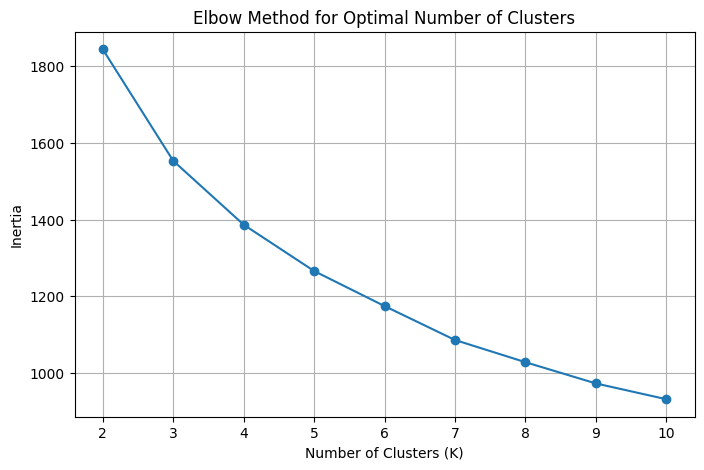

In [ ]:
from sklearn.cluster import KMeans

k_values = range(2, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
for k, value in zip(k_values, inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 1844.06
K = 3: Inertia = 1553.42
K = 4: Inertia = 1386.86
K = 5: Inertia = 1266.15
K = 6: Inertia = 1174.76
K = 7: Inertia = 1086.36
K = 8: Inertia = 1028.49
K = 9: Inertia = 973.14
K = 10: Inertia = 932.00


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(k_values, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

Silhouette Scores:
K = 2: Silhouette Score = 0.2903
K = 3: Silhouette Score = 0.2594
K = 4: Silhouette Score = 0.1885
K = 5: Silhouette Score = 0.1916
K = 6: Silhouette Score = 0.2009
K = 7: Silhouette Score = 0.1958
K = 8: Silhouette Score = 0.1852
K = 9: Silhouette Score = 0.1965
K = 10: Silhouette Score = 0.1905


In [ ]:
# Final K-Means model with 2 clusters
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df["Cluster"] = cluster_labels

print("Cluster assignment completed!")
print("\nNumber of customers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Cluster assignment completed!

Number of customers in each cluster:
Cluster
0    252
1    188
Name: count, dtype: int64


In [ ]:
# Calculate average spending for each cluster
cluster_profile = df.groupby("Cluster")[features].mean().round(2)

print("Average spending by cluster:")
print(cluster_profile)

Average spending by cluster:
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0        13973.13   2401.75   2918.71  3705.67            491.94     1038.04
1         9355.87  10346.36  14697.06  2222.45           6084.51     2177.43


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_.round(4))

print("\nTotal variance explained by 2 components:")
print(round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio:
[0.4408 0.2719]

Total variance explained by 2 components:
0.7127


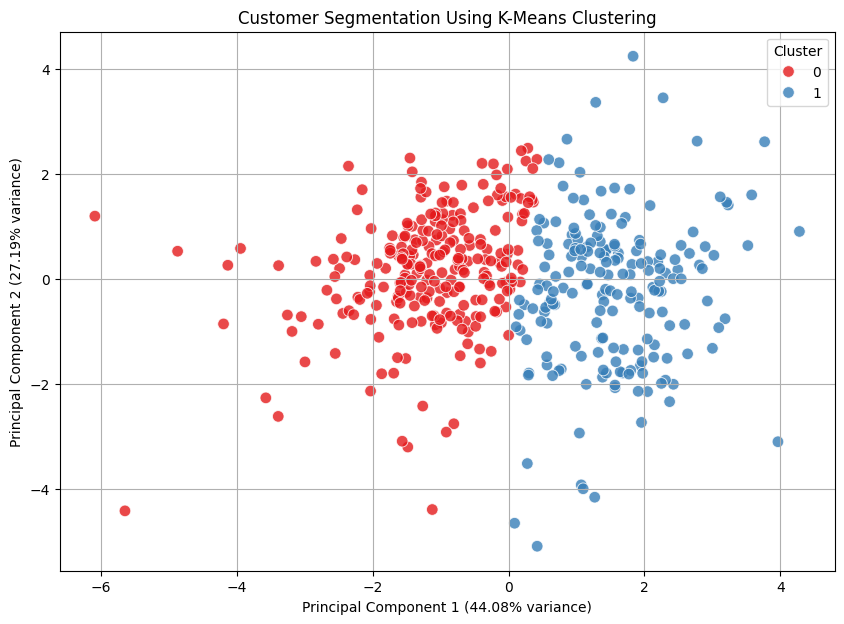

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70,
    alpha=0.8
)

plt.title("Customer Segmentation Using K-Means Clustering")
plt.xlabel("Principal Component 1 (44.08% variance)")
plt.ylabel("Principal Component 2 (27.19% variance)")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

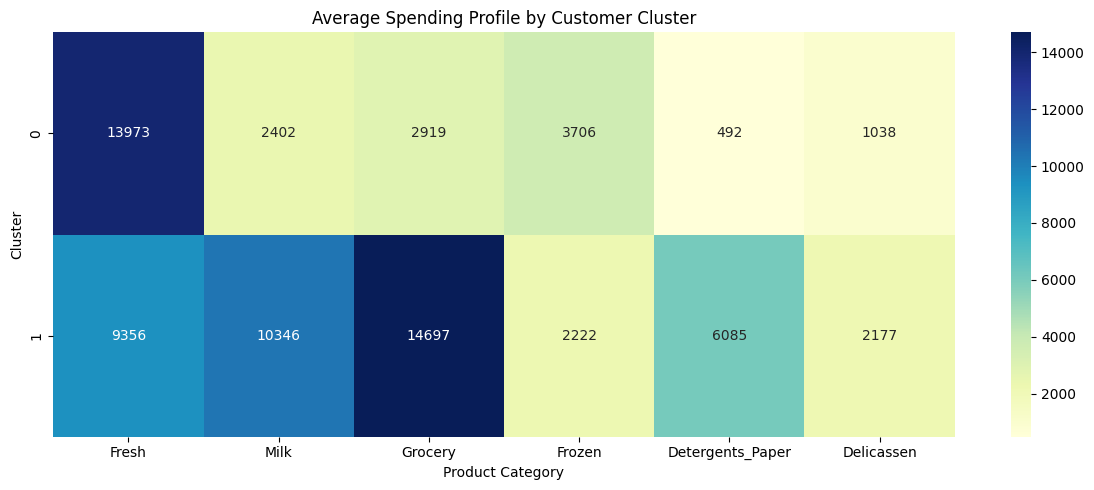

In [ ]:
# Create cluster profile using average original spending
cluster_profile = df.groupby("Cluster")[features].mean()

plt.figure(figsize=(12, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Spending Profile by Customer Cluster")
plt.xlabel("Product Category")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [ ]:
ratio = cluster_profile.loc[1] / cluster_profile.loc[0]

print("Cluster 1 to Cluster 0 spending ratio:")
print(ratio.round(2))

Cluster 1 to Cluster 0 spending ratio:
Fresh                0.67
Milk                 4.31
Grocery              5.04
Frozen               0.60
Detergents_Paper    12.37
Delicassen           2.10
dtype: float64


In [ ]:
print("Channel distribution within each cluster (%):")
print(
    pd.crosstab(
        df["Cluster"],
        df["Channel"],
        normalize="index"
    ).round(3) * 100
)

print("\nRegion distribution within each cluster (%):")
print(
    pd.crosstab(
        df["Cluster"],
        df["Region"],
        normalize="index"
    ).round(3) * 100
)

Channel distribution within each cluster (%):
Channel     1     2
Cluster            
0        96.8   3.2
1        28.7  71.3

Region distribution within each cluster (%):
Region      1     2     3
Cluster                  
0        19.0  11.1  69.8
1        15.4  10.1  74.5
